In [41]:
from collections import namedtuple
import gzip
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm
import numpy as np 
from matplotlib import pyplot as plt
import zipfile
import io
from fast_edit_distance import edit_distance, sub_edit_distance
from io import StringIO
import multiprocessing as mp
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor, as_completed

# a light class for a read in fastq file
read_tuple = namedtuple('read_tuple', ['id', 'seq', 'q_letter'])
def fastq_parser(file_handle):
    while True:
        id = next(file_handle, None)
        if id is None:
            break
        seq = next(file_handle)
        next(file_handle) # skip  '+'
        q_letter = next(file_handle)
        yield read_tuple(id[1:].split()[0], seq.strip(), q_letter.strip()) #每次yield一条read的信息

# split any iterator in to batches  
def batch_iterator(iterator, batch_size):
    """generateor of batches of items in a iterator with batch_size.
    """
    batch = []
    i=0
    for entry in iterator:
        i += 1
        batch.append(entry)
        
        if i == batch_size:
            yield batch
            batch = []
            i = 0
    if len(batch):  #保证批次处理的时候，最后一批不满足batch_size的那些数据，也可以被yield
        yield batch

def read_batch_generator(fastq_fns, batch_size):   #输出batch size read info
    """Generator of barches of reads from list of fastq files

    Args:
        fastq_fns (list): fastq filenames
        batch_size (int, optional):  Defaults to 100.
    """
    for fn in fastq_fns:
        if str(fn).endswith('.gz'):
            with gzip.open(fn, "rt") as handle:
                fastq = fastq_parser(handle)
                read_batch = batch_iterator(fastq, batch_size=batch_size)
                for batch in read_batch:
                    yield batch
        else:
            with open(fn, "r") as handle:
                fastq = fastq_parser(handle)
                read_batch = batch_iterator(fastq, batch_size=batch_size)
                for batch in read_batch:
                    yield batch


In [2]:
def reverse_complement(seq):
	'''
	Args: <str>
		queried seq
	Returns: <str>
		reverse_complement seq
	'''
	comp = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 
					'a': 't', 'c': 'g', 'g': 'c', 't': 'a'}
	letters = \
		[comp[base] if base in comp.keys() else base for base in seq]
	return ''.join(letters)[::-1]

In [3]:
def polyA_trimming_idx(seq, seed="AAAA", window=10, min_A=7, min_tail_len=8):
    """
    从 read 末端往前检测 polyA，返回 polyA 起始的绝对坐标（0-based）。
    若未检测到则返回 None。
    """
    s = seq.upper()
    anchor = s.rfind(seed)  # 最右侧 seed 的起点（绝对坐标）
    if anchor == -1:
        return None

    polyA_start = anchor  # 先把 polyA 起点放在 seed 起点
    i = anchor - 1        # 从 seed 之前的碱基开始，向左延伸

    while i >= 0:
        if s[i] == 'A':
            polyA_start = i
            i -= 1
            continue
        left = max(0, i - window + 1)
        if s[left:i+1].count('A') >= min_A:
            polyA_start = i
            i -= 1
            continue
        break

    # 确保 polyA 足够长
    if len(s) - polyA_start < min_tail_len:
        return None
    return polyA_start
    
def polyA_trimming_idx_neg(seq, **kwargs):
    idx_abs = polyA_trimming_idx(seq, **kwargs)  # 用上面的绝对坐标函数
    if idx_abs is None:
        return None
    return idx_abs - len(seq)  # 负数：从末尾往前的偏移

In [4]:
fl_fq = ["/home/liyy/2.project/ScRNA-Seq/Glycine_Sc/6011_4/6011.full-length.fq.gz"] #3,176,234 read count 
batch_size = 1000
read_batchs = read_batch_generator(fl_fq, batch_size)

### 获取Glycine后的数据结果  这里有个多线程待解决

In [5]:
def rfind_with_negative(s, sub):
    pos = s.rfind(sub)
    if pos == -1:
        return -1  # not found 
    return pos - len(s)

In [6]:
read_ids = []
putative_bcs = []
putative_bc_min_qs = []
bc_fixed_locs = [] #固定序列反向互补的5'位置 
#raw_bc_pass = []
umis = []
umi_fixed_locs = []  #umi固定序列的5'端位置
#trim_idxs = []
post_umi_flankings = []
polyA_starts = []
BC_fixed = "GGAAGG" #reverse complement
umi_fixed = "CATCG"

In [8]:
for batch in read_batchs:
    for read_info in batch:
        part_id = read_info.id
        part_seq = read_info.seq[-30:]
        part_qv = read_info.q_letter[-30:]
        read_ids.append(part_id)
        putative_bc_min_q = None
        umi = None
        umi_fixed_loc= None
        post_umi_flanking = None
        polyA_start = None
        BC_fixed_loc = rfind_with_negative(part_seq, BC_fixed)
        #print(BC_fixed_loc)
        bc_fixed_locs.append(BC_fixed_loc)
        if BC_fixed_loc == -16:
            putative_bc = read_info.seq[-26:]
            putative_bcs.append(putative_bc)
            putative_bc_min_q = min([ord(x) for x in part_qv[-26:]]) -33
            putative_bc_min_qs.append(putative_bc_min_q)
            #locate umi
            find_umi_seq = read_info.seq[-36:-26] #barcode再往前10bp去找固定序列
            umi_fixed_loc_re = rfind_with_negative(find_umi_seq, umi_fixed) 
            if umi_fixed_loc_re != -1:
                umi_fixed_loc = umi_fixed_loc_re - 26 #相对于read的位置
                umi_fixed_locs.append(umi_fixed_loc)
                umi = read_info.seq[umi_fixed_loc - 10 : umi_fixed_loc + 5]
                umis.append(umi)
                post_umi_flanking = read_info.seq[umi_fixed_loc - 10-5 : umi_fixed_loc - 10]
                post_umi_flankings.append(post_umi_flanking)
                #鉴定polyA的起始位置
                seq_polyA = read_info.seq[umi_fixed_loc - 10 -100:umi_fixed_loc - 10]
                last_polyA_idx = polyA_trimming_idx_neg(seq_polyA)
                if last_polyA_idx: #可以检测到polyA
                    polyA_start =  last_polyA_idx - 10 + umi_fixed_loc #相对于整个read
                    polyA_starts.append(polyA_start)
                else:
                    polyA_starts.append(polyA_start)
            else:
                umis.append(umi)
                umi_fixed_locs.append(umi_fixed_loc)
                post_umi_flankings.append(post_umi_flanking)
                polyA_starts.append(polyA_start)
                
        elif BC_fixed_loc < -16:
            putative_bc = read_info.seq[BC_fixed_loc-10 : BC_fixed_loc+16]
            putative_bcs.append(putative_bc)
            putative_bc_min_q = min([ord(x) for x in read_info.q_letter[BC_fixed_loc-10:BC_fixed_loc+16]]) -33
            putative_bc_min_qs.append(putative_bc_min_q)
            #locate umi
            find_umi_seq = read_info.seq[BC_fixed_loc - 10 -10 :BC_fixed_loc - 10] #barcode再往前10bp去找固定序列
            umi_fixed_loc_re = rfind_with_negative(find_umi_seq, umi_fixed)
            
                
            if umi_fixed_loc_re != -1:
                umi_fixed_loc = umi_fixed_loc_re + BC_fixed_loc - 10 #相对于read的位置 修改了一个bug
                umi_fixed_locs.append(umi_fixed_loc)
                umi = read_info.seq[umi_fixed_loc - 10 : umi_fixed_loc + 5]
                umis.append(umi)
                post_umi_flanking = read_info.seq[umi_fixed_loc - 10-5 : umi_fixed_loc - 10]
                post_umi_flankings.append(post_umi_flanking)
                #if read_info.id == "250F302306011_11_158_8281_196090449_14000_1_14.58":
                #    print(BC_fixed_loc)
                #    print(umi_fixed_loc_re)
                #    print(umi)
                #    print(post_umi_flanking)
                
                #鉴定polyA的起始位置
                seq_polyA = read_info.seq[umi_fixed_loc - 10 -100 :umi_fixed_loc - 10]
                last_polyA_idx = polyA_trimming_idx_neg(seq_polyA)
                if last_polyA_idx: #可以检测到
                    polyA_start =  last_polyA_idx - 10 + umi_fixed_loc #相对于整个read
                    polyA_starts.append(polyA_start)
                else:
                    polyA_starts.append(polyA_start)
                
            else:
                umis.append(umi)
                umi_fixed_locs.append(umi_fixed_loc)
                post_umi_flankings.append(post_umi_flanking)
                polyA_starts.append(polyA_start)
            
            
        elif BC_fixed_loc == -1: 
            #putative_bcs.append("No BC")
            putative_bcs.append(part_seq[-26:]) #直接输出后26bp
            putative_bc_min_qs.append(putative_bc_min_q)
            umi_fixed_locs.append(umi_fixed_loc)
            umis.append(umi)
            post_umi_flankings.append(post_umi_flanking)
            polyA_starts.append(polyA_start)
        else:#BC_fixed_loc>-16 右半段barcode不完全 #根据umi来判断barcode，即使是残缺的barcode
            #locate umi
            find_umi_seq = read_info.seq[BC_fixed_loc - 10 -10 :BC_fixed_loc - 10] #barcode再往前10bp去找固定序列
            umi_fixed_loc_re = rfind_with_negative(find_umi_seq, umi_fixed)
            if umi_fixed_loc_re != -1:
                umi_fixed_loc = umi_fixed_loc_re + BC_fixed_loc - 10 #相对于read的位置 
                umi_fixed_locs.append(umi_fixed_loc)
                umi = read_info.seq[umi_fixed_loc - 10 : umi_fixed_loc + 5]
                umis.append(umi)
                post_umi_flanking = read_info.seq[umi_fixed_loc - 10-5 : umi_fixed_loc - 10]
                post_umi_flankings.append(post_umi_flanking)
                #根据umi来定位barcode 
                putative_bc_start_loc = umi_fixed_loc + 5 
                putative_bc = read_info.seq[putative_bc_start_loc:]
                putative_bcs.append(putative_bc)
                putative_bc_min_q = min([ord(x) for x in read_info.q_letter[putative_bc_start_loc:]]) -33
                putative_bc_min_qs.append(putative_bc_min_q)

                #if read_info.id == "250F302306011_13_7768_14189_229630721_8199_2_14.36":
                #    print(BC_fixed_loc)
                #    print(umi_fixed_loc_re)
                #    print(umi)
                #    print(post_umi_flanking)
                #鉴定polyA的起始位置
                seq_polyA = read_info.seq[umi_fixed_loc - 10 -100:umi_fixed_loc - 10]
                last_polyA_idx = polyA_trimming_idx_neg(seq_polyA)
                if last_polyA_idx: #可以检测到
                    polyA_start =  last_polyA_idx - 10 + umi_fixed_loc #相对于整个read
                    polyA_starts.append(polyA_start)
                else:
                    polyA_starts.append(polyA_start)
                
            else: #也没有找到umi
                putative_bcs.append(part_seq[-26:])
                putative_bc_min_qs.append(putative_bc_min_q)
                umi_fixed_locs.append(umi_fixed_loc)
                umis.append(umi)
                post_umi_flankings.append(post_umi_flanking)
                polyA_starts.append(polyA_start)
                
        #break

    #break


rst_df = pd.DataFrame(
        {'read_id': read_ids,
         'putative_bc': putative_bcs,
         'bc_fixed_locs':bc_fixed_locs,
         'putative_bc_min_qs': putative_bc_min_qs,
        'putative_umi': umis,
         'umi_fixed_locs':umi_fixed_locs,
         'post_umi_flankings':post_umi_flankings,
         'polyA_starts':polyA_starts
        }
        )

In [9]:
rst_df.to_csv("./putative_bc.csv",index=False)

In [10]:
putative_bcs[:20]

['GCACCGGACGGGAAGGCCGTGCAGAA',
 'CGATTGATATGGAAGGCAATCTACTC',
 'GAATCCTAGCGGAAGGTGGTACTGAC',
 'TATGACAAGCGGAAGGGTATCTTGCA',
 'TTGGAATCGGGGAAGGTGGCGAACGT',
 'GCGCTGTCACGGAAGGCCTGAGCCTA',
 'CAGTCTGTGGGGAAGGCACATTCTTC',
 'TGAGTGAACTGGAAGGCGGAGACCG',
 'TGGCGATAATGGAAGGCGACCGTAGT',
 'ACGGTCTTGCGAAGCGAATTTGGACT',
 'TTATCAATCGGGAAGGTTCATTCTGT',
 'AGCCGCTAATGGAAGGTCGTTGGAC',
 'CCTGGTGCACGGAAGGCTCCGTCTAC',
 'AGAAAAAAAAAAAAAAAAAAAAAAAA',
 'GCCTACGAAGAGAAGGGAGGACGGAA',
 'GGGTCCATCAGGAAGGCAGCGAATTA',
 'TCTATCCTGTGGAAGGGATCGACTT',
 'CGAAGCGCTAGGAAGGCTATAGTCTC',
 'AAAAAAAAAAAAAAAAAAAAAAAAAA',
 'TAAAAGACCGCCGGGAAGGAATCCAC']

### 根据superlist进行矫正

In [11]:
def default_count_threshold_calculation(count_array, exp_cells):
    top_count = np.sort(count_array)[::-1][:exp_cells]
    return np.quantile(top_count, 0.95)/20

In [12]:
def knee_plot(counts, threshold=None, out_fn = 'knee_plot.png'):
    """
    Plot knee plot using the high-confidence putative BC counts

    Args:
        counts (list): high-confidence putative BC counts
        threshold (int, optional): a line to show the count threshold. Defaults to None.
    """
    counts = sorted(counts)[::-1]
    plt.figure(figsize=(8, 8))
    plt.title(f'Barcode rank plot (from high-quality putative BC)')
    plt.loglog(counts,marker = 'o', linestyle="", alpha = 1, markersize=6)
    plt.xlabel('Barcodes')
    plt.ylabel('Read counts')
    plt.axhline(y=threshold, color='r', linestyle='--', label = 'cell calling threshold')
    plt.legend()
    plt.savefig(out_fn)

In [16]:
def get_bc_whitelist(raw_bc_count, full_bc_whitelist=None, exp_cells=None, out_plot_fn = None,empty_max_count = np.inf):
    percentile_count_thres = default_count_threshold_calculation
    whole_whitelist = []
    if full_bc_whitelist.endswith('.zip'):
        with zipfile.ZipFile(full_bc_whitelist) as zf:
            # check if there is only 1 file
            assert len(zf.namelist()) == 1

            with io.TextIOWrapper(zf.open(zf.namelist()[0]), encoding="utf-8") as f:
                for line in f:
                    whole_whitelist.append(reverse_complement(line.strip()))
    else:
        with open(full_bc_whitelist, 'r') as f:
            for line in f:
                whole_whitelist.append(reverse_complement(line.strip()))
    
    whole_whitelist = set(whole_whitelist)
    raw_bc_count = {k:v for k,v in raw_bc_count.items() if k in whole_whitelist}
    #print(len(raw_bc_count))
    t = percentile_count_thres(list(raw_bc_count.values()), exp_cells) #t是
    knee_plot(list(raw_bc_count.values()), t, out_plot_fn)
    cells_bc = {k:v for k,v in raw_bc_count.items() if v > t}
    
    ept_bc = []
    ept_bc_max_count = min(cells_bc.values()) #空bc最大的read支持数
    ept_bc_max_count = min(ept_bc_max_count, empty_max_count)
    #print(ept_bc_max_count)

    ept_bc_candidate = [k for k,v in raw_bc_count.items() if v < ept_bc_max_count]
    #print(len(ept_bc_candidate))
    for k in ept_bc_candidate:
        if min([edit_distance(k, x, max_ed = DEFAULT_EMPTY_DROP_MIN_ED) for x in cells_bc.keys()]) >= DEFAULT_EMPTY_DROP_MIN_ED:
            ept_bc.append(k)
            #print(len(ept_bc))
        # we don't need too much BC in this list
        if len(ept_bc) >  DEFAULT_EMPTY_DROP_NUM:
            break
    return cells_bc, ept_bc

In [17]:
dfs = pd.read_csv("./putative_bc.csv", chunksize=1_000_000)   #读取上一步输出的putative_bc.csv
minQ = 10
out_whitelist_fn = "./whitelist.csv"
out_emptydrop_fn  = "./emtpy_bc_list.csv"
full_bc_whitelist = "/home/liyy/1.data/C4_Cyclone/C4_blaze/C4_26bp.txt"
exp_cells = 10000
out_plot_fn = "knee_plot.png"
DEFAULT_EMPTY_DROP_MIN_ED = 5
DEFAULT_EMPTY_DROP_NUM = 2000 

In [18]:
raw_bc_count = Counter()
for df in tqdm(dfs, desc = 'Counting high-quality putative BC', unit='M reads'): #按块读取 CSV → 过滤掉低质量 putative_bc → 统计高质量 putative_bc 的出现次数 → 累加到总的 Counter。
        raw_bc_count += Counter(df[
        df.putative_bc_min_qs >=minQ].putative_bc.value_counts().to_dict()) #Counter({'GCGATAGTCACCTTCCGATGATTGCA': 166,'GACCTAATGGCCTTCCACGAGACTTG': 157,...}) 已经排序
#print(raw_bc_count.values())

Counting high-quality putative BC: 4M reads [00:09,  2.49s/M reads]


In [21]:
raw_bc_count

Counter({'CGCGCATCGAGGAAGGGAAGCAGTGA': 1119,
         'TGCAATCATCGGAAGGTGACTATCGC': 1013,
         'CATGTGCGCAGGAAGGCCATAACGTA': 1005,
         'TCTAGACACTGGAAGGTGTTCTTCTC': 957,
         'CGAAGATCATGGAAGGTCAAGTAGTG': 890,
         'TTAGAACCATGGAAGGGCCGTGACTT': 852,
         'CGCGCGGTCAGGAAGGCCATTGGAAG': 831,
         'AGAGTTGCGTGGAAGGAAGGATAATG': 816,
         'CGACGAAGCCGGAAGGTTGGAGAGTC': 796,
         'CAAGTCTCGTGGAAGGCCATTAGGTC': 774,
         'GAGAGCAGTCGGAAGGGCACGGACAT': 744,
         'ACGGTTCTGTGGAAGGAGAGATGATA': 738,
         'TGAAGATTACGGAAGGAGCTTCTATA': 738,
         'AGGTACCTACGGAAGGTGTATGTCAC': 728,
         'GCGTCGTTACGGAAGGTATTCCGATA': 725,
         'AGGTCCATCAGGAAGGCAGCGAATTA': 724,
         'AAGCATAGCTGGAAGGTGGTCATGCC': 723,
         'GATCGTTCGCGGAAGGTCGATCCGTG': 715,
         'CCGGCGCAACGGAAGGTGCAATCATC': 700,
         'ACCAGTGCATGGAAGGCACAATGTTA': 681,
         'AGAGTCTATTGGAAGGCACAATGTTA': 656,
         'TGGAGCTCCTGGAAGGTGTGTGAATG': 631,
         'GCATAGTCATGGAAGGATA

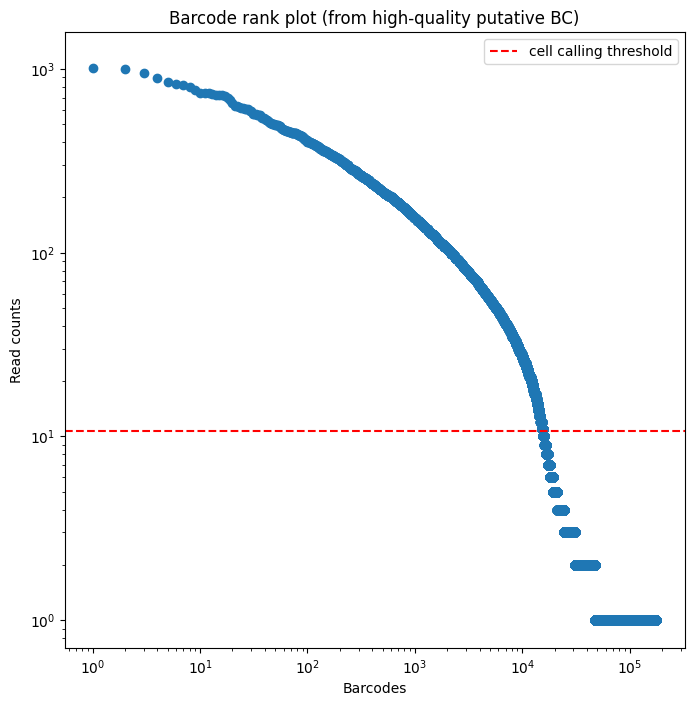

In [20]:
#try:
bc_whitelist, ept_bc = get_bc_whitelist(raw_bc_count=raw_bc_count, full_bc_whitelist=full_bc_whitelist, exp_cells=exp_cells, out_plot_fn = out_plot_fn)

with open(out_whitelist_fn, 'w') as f:
    for k in bc_whitelist.keys():
        f.write(k+'\n')
with open(out_emptydrop_fn, 'w') as f:
    for k in ept_bc:
        f.write(k+'\n')
#except Exception as e: 
#    print("Error: Failed to get whitelist. Please check the input files and settings.")
#else:
#    print(f'Whitelist saved as `{out_whitelist_fn}`!')

In [22]:
len(bc_whitelist)

15630

### 以上没有问题

### demultiplex and assign reads test

In [15]:
putative_bc_csv = "./putative_bc.csv"
fastq_fns = ["/home/liyy/2.project/ScRNA-Seq/Glycine_Sc/6011_4/6011.full-length.fq.gz"]
whitelsit_csv = "./whitelist.csv"

In [16]:
read_idx = 0
putative_bc_f = open(putative_bc_csv, 'r')
putative_bc_header = next(putative_bc_f)

In [18]:
putative_bc_header

'read_id,putative_bc,bc_fixed_locs,putative_bc_min_qs,putative_umi,umi_fixed_locs,post_umi_flankings\n'

In [30]:
class read_fastq:
    """This class is for mimic the Bio.SeqIO fastq record. The SeqIO is not directly used because it's slow.
    """
    def __init__(self, title, sequence, qscore, quality_map = False):
        self.id = title.split()[0].strip("@")
        self.seq = sequence
        self.qscore = qscore

In [78]:
for fn in fastq_fns:
    if str(fn).endswith('.gz'):
        with gzip.open(fn, "rt") as handle:
            fastq =\
                (read_fastq(title, sequence, qscore) for title, sequence, qscore in fastq_parser(handle))

            batch_iter = batch_iterator(fastq, batch_size=batch_size)
            for batch in batch_iter:
                batch_len = len(batch)
                batch_bc_df = pd.read_csv(
                        StringIO(
                            putative_bc_header + \
                            ''.join([next(putative_bc_f) for x in range(batch_len)])
                        ))
                #yield batch, read_idx, batch_bc_df
                read_idx += batch_len
                print(batch_bc_df)
                break
    else:
        with open(fn) as handle:
            fastq =\
                (read_fastq(title, sequence, qscore) for title, sequence, qscore in fastq_parser(handle))
            read_batch = batch_iterator(fastq, batch_size=batch_size)
            for batch in read_batch:
                batch_len = len(batch)
                batch_bc_df = pd.read_csv(
                    StringIO( putative_bc_header + \
                    ''.join([next(putative_bc_f) for x in range(batch_len)]))
                )

                #yield batch, read_idx, batch_bc_df
                read_idx += batch_len
#putative_bc_f.close()

                                               read_id  \
0    250F302306011_11_189_10128_196076064_11010_0_1...   
1    250F302306011_11_7526_9970_192395919_21242_3_1...   
2    250F302306011_13_5384_14012_225141126_12157_1_...   
3    250F302306011_11_151_6689_196071554_18096_3_14.53   
4    250F302306011_11_192_9886_196073109_13496_1_16.26   
..                                                 ...   
995  250F302306011_13_4339_11700_222218847_7843_1_1...   
996   250F302306011_11_231_8614_196408986_9996_0_15.58   
997  250F302306011_11_112_8473_196404364_13519_3_14.21   
998  250F302306011_11_187_3296_196377041_34185_3_16.86   
999  250F302306011_11_156_9817_196386189_16909_0_14.59   

                    putative_bc  bc_fixed_locs  putative_bc_min_qs  \
0    GCACCGGACGGGAAGGCCGTGCAGAA            -16                 6.0   
1    CGATTGATATGGAAGGCAATCTACTC            -16                15.0   
2    GAATCCTAGCGGAAGGTGGTACTGAC            -16                 8.0   
3    TATGACAAGCGGAAGGGT

In [81]:
whitelist = [] 
with open(whitelsit_csv, 'r') as f:
    for line in f:
        whitelist.append(line.split('-')[0].strip())

In [82]:
whitelist

['CGCGCATCGAGGAAGGGAAGCAGTGA',
 'CATGTGCGCAGGAAGGCCATAACGTA',
 'TCTAGACACTGGAAGGTGTTCTTCTC',
 'TGCAATCATCGGAAGGTGACTATCGC',
 'CGAAGATCATGGAAGGTCAAGTAGTG',
 'CAAGTCTCGTGGAAGGCCATTAGGTC',
 'CGCGCGGTCAGGAAGGCCATTGGAAG',
 'CGACGAAGCCGGAAGGTTGGAGAGTC',
 'ACGGTTCTGTGGAAGGAGAGATGATA',
 'GCGTCGTTACGGAAGGTATTCCGATA',
 'TTAGAACCATGGAAGGGCCGTGACTT',
 'AGGTCCATCAGGAAGGCAGCGAATTA',
 'TGAAGATTACGGAAGGAGCTTCTATA',
 'AAGCATAGCTGGAAGGTGGTCATGCC',
 'CCGGCGCAACGGAAGGTGCAATCATC',
 'GAGAGCAGTCGGAAGGGCACGGACAT',
 'AGGTACCTACGGAAGGTGTATGTCAC',
 'GATCGTTCGCGGAAGGTCGATCCGTG',
 'AGAGTCTATTGGAAGGCACAATGTTA',
 'ACCAGTGCATGGAAGGCACAATGTTA',
 'TTCGCTCGATGGAAGGGCATGTCGAT',
 'GCATAGTCATGGAAGGATATTGTCGT',
 'AGGTCCATCAGGAAGGACCAAGGTCG',
 'CAGATACGTTGGAAGGCCGTTGTCTC',
 'GCTCAGTGCCGGAAGGTGACGACAGG',
 'CCACCTATGTGGAAGGTGCTCATCGG',
 'GTATGTCCTGGGAAGGCCTACGTACG',
 'TGGAGCTCCTGGAAGGTGTGTGAATG',
 'CATCCGTTACGGAAGGTCAGTGAGTC',
 'ACGTGTTAGAGGAAGGTTCCAGTGAT',
 'GACAAGGTGTGGAAGGTACAGGAGAA',
 'AATGAACTGTGGAAGGACCTGACTGC',
 'CTCATT

In [89]:
from tqdm import tqdm
import time

pbar = tqdm(unit="Reads", desc='Processed')

for i in range(100):
    time.sleep(0.05)
    pbar.update(1)

pbar.close()

Processed: 100Reads [00:05, 19.83Reads/s]


In [92]:
len(set(whitelist))

15520

In [23]:
for i in rst_df[:100].itertuples():
    print(i)
    break

Pandas(Index=0, read_id='250F302306011_11_189_10128_196076064_11010_0_14.52', putative_bc='GCACCGGACGGGAAGGCCGTGCAGAA', bc_fixed_locs=-16, putative_bc_min_qs=6.0, putative_umi=None, umi_fixed_locs=nan, post_umi_flankings=None)


### 08291702  根据前两步结果，测试demultiplex各个函数

In [23]:
def _read_and_bc_batch_generator_with_idx(fastq_fns, putative_bc_csv, batch_size):
    """Generator of barches of reads from list of fastq files with the idx of the first read
    in each batch

    Args:
        fastq_fns (list): fastq filenames
        batch_size (int, optional):  Defaults to 1000.
    """
    read_idx = 0
    putative_bc_f = open(putative_bc_csv, 'r')
    putative_bc_header = next(putative_bc_f)

    for fn in fastq_fns:
        if str(fn).endswith('.gz'):
            with gzip.open(fn, "rt") as handle:
                fastq =\
                    (read_fastq(title, sequence, qscore) for title, sequence, qscore in fastq_parser(handle))

                batch_iter = batch_iterator(fastq, batch_size=batch_size)
                
                for batch in batch_iter:
                    batch_len = len(batch)
                    batch_bc_df = pd.read_csv(
                        StringIO(
                            putative_bc_header + \
                            ''.join([next(putative_bc_f) for x in range(batch_len)])
                        ))
                    yield batch, read_idx, batch_bc_df
                    read_idx += batch_len
        else:
            with open(fn) as handle:
                fastq =\
                    (read_fastq(title, sequence, qscore) for title, sequence, qscore in fastq_parser(handle))
                read_batch = batch_iterator(fastq, batch_size=batch_size)
                for batch in read_batch:
                    batch_len = len(batch)
                    batch_bc_df = pd.read_csv(
                        StringIO( putative_bc_header + \
                        ''.join([next(putative_bc_f) for x in range(batch_len)]))
                    )

                    yield batch, read_idx, batch_bc_df #[read_id_seq_qv,....,] 0,1000,2000... df
                    read_idx += batch_len
    putative_bc_f.close()

In [24]:
def _match_bc_row(row, whitelist, max_ed, minQ):
    
    strand = '+'
    
    if minQ and row.putative_bc_qscore < minQ: #没有起到作用？
        return ['', '', '']

    if not row.putative_bc or row.putative_bc in whitelist: #若bc为空或者bc在白名单中，直接返回
        return [row.putative_bc, row.putative_umi, strand]
    else: #若这个barcode不为空，但是不在白名单中，需要尝试纠错
        bc = row.putative_bc
    
    best_ed = max_ed #2
    bc_hit = ''

    #对于不在white list中的barcode 这个是whitelist.csv
    #以下代码暂无问题 202508281418
    for i in whitelist:
        ed, end_idx = sub_edit_distance(i, bc, best_ed)  #直接和white list中的做比较
        if ed < best_ed:
            best_ed = ed
            bc_hit = i #最佳匹配到的一个white list中的barcode
        elif ed == best_ed:
            if not bc_hit:
                bc_hit = i
            else: 
                bc_hit = 'ambiguous'
                best_ed -= 1
                if best_ed < 0:
                    return ['', row.putative_umi, strand]
    
    if bc_hit == 'ambiguous' or bc_hit == '':
        return ['', row.putative_umi, strand]
    else:
        pass
            
    out_umi = row.putative_umi
    return [bc_hit, out_umi, strand]

In [25]:
def assign_read_batches(r_batch, whitelist, max_ed, gz, minQ=0):
    read_batch, start_df_idx, df = r_batch
    df = df.fillna('')
    whitelist = set(whitelist)
    out_buffer = ''
    
    new_cols = []
    for row in df.itertuples():
        new_cols.append(_match_bc_row(row, whitelist, max_ed, minQ))
    
    df[['BC_corrected','putative_umi', 'strand']] = new_cols
    demul_read_count = sum(df.BC_corrected!='') #最终所有的barcode（包括矫正回来的）

    for r, bc in zip(read_batch, df.itertuples()):
        try:
            assert bc.read_id == r.id            
        except AssertionError:
            err_msg("Different order in putative bc file and input fastq!", printit = True)
            sys.exit()
        if not bc.BC_corrected or not bc.putative_umi: #BC_corrected这一列有没有  并且putative_umi这一列有没有 目前是完全匹配，所以可能比例较低
            continue
        #加上polyA的判断机制吧
        if bc.polyA_starts: #若polyA_starts不为空 目前为空的原因是umi固定序列左边的read太少，有可能是umi序列不完整
            seq = r.seq[:int(bc.polyA_starts)]
            qscore = r.qscore[:int(bc.polyA_starts)]
        # write to fastq
        out_buffer += f"@{bc.BC_corrected}_{bc.putative_umi}#{bc.read_id}_{bc.strand}\tCB:Z:{bc.BC_corrected}\tUB:Z:{bc.putative_umi}\n"
        out_buffer += str(seq) + '\n' 
        out_buffer += '+\n'
        out_buffer += qscore + '\n'
    
    if gz: #如果要求输出是gz文件
        b_out_buffer = gzip.compress(out_buffer.encode('utf-8'))
    else:
        b_out_buffer = out_buffer.encode('utf-8')

    return df, b_out_buffer, demul_read_count, len(read_batch)
        
        
        


In [39]:
def assign_read(fastq_fns=None, fastq_out=None, putative_bc_csv=None, 
                    whitelsit_csv=None, max_ed=None,n_process=None, batchsize=None, minQ=0):
    
    gz = fastq_out.endswith('.gz') #判断输出文件是否为gz文件
    r_batches = \
        _read_and_bc_batch_generator_with_idx(fastq_fns, putative_bc_csv, batchsize)
    
    whitelist = [] 
    with open(whitelsit_csv, 'r') as f:
        for line in f:
            whitelist.append(line.split('-')[0].strip())

    if n_process == 1:
        demul_count_tot = 0
        count_tot = 0
        with open(fastq_out, 'wb') as output_handle:
            pbar = tqdm(unit="Reads", desc='Processed')
            for r_batch in r_batches:
                _, b_fast_str, demul_count, read_count = assign_read_batches(r_batch, whitelist, max_ed,  gz, minQ=0)
                demul_count_tot += demul_count
                count_tot += read_count
                output_handle.write(b_fast_str)
                pbar.update(read_count) #
        green_msg(f"Reads assignment completed. Demultiplexed read saved in {fastq_out}!")
        
    else:
        rst_futures = multiprocessing_submit(assign_read_batches, 
                            r_batches, 
                            n_process=n_process,
                            schduler = "process",
                            pbar_func=lambda x: len(x[0]),
                            whitelist = whitelist,
                            max_ed = max_ed,
                            gz = gz)

        demul_count_tot = 0
        count_tot = 0
        df_list = []
        with open(fastq_out, 'wb') as output_handle:
            for f in rst_futures:
                df, b_fast_str, demul_count, read_count = f.result()
                demul_count_tot += demul_count
                count_tot += read_count
                output_handle.write(b_fast_str)
    
        green_msg(f"Reads assignment completed. Demultiplexed read saved in {fastq_out}!")
    
    return demul_count_tot, count_tot

In [27]:
def err_msg(msg, printit = False):
    CRED = '\033[91m'
    CEND = '\033[0m'
    if printit:
        print(CRED + msg + CEND)
    else:
        return CRED + msg + CEND

def warning_msg(msg, printit = False):
    CRED = '\033[93m'
    CEND = '\033[0m'
    if printit:
        print(CRED + msg + CEND)
    else:
        return CRED + msg + CEND

def green_msg(msg, printit = False):
    CRED = '\033[92m'
    CEND = '\033[0m'
    if printit:
        print(CRED + msg + CEND)
    else:
        return CRED + msg + CEND

In [61]:
putative_bc_csv = "./putative_bc.csv"
fastq_fns = ["/home/liyy/2.project/ScRNA-Seq/Glycine_Sc/6011_4/6011.full-length.fq.gz"]
whitelsit_csv = "./whitelist.csv"
fastq_out = "matched_reads.fastq.gz"
max_ed = 3 #需要多尝试几次
batchsize = 10000


In [57]:
def multiprocessing_submit(func, iterator, n_process=mp.cpu_count()-1 ,
                           pbar=True, pbar_unit='Read',pbar_func=len, 
                           schduler = 'process', *arg, **kwargs):
    """multiple processing or threading, 

    Args:
        func: function to be run parallely
        iterator: input to the function in each process/thread
        n_process (int, optional): number of cores or threads. Defaults to mp.cpu_count()-1.
        pbar (bool, optional): Whether or not to output a progres bar. Defaults to True.
        pbar_unit (str, optional): Unit shown on the progress bar. Defaults to 'Read'.
        pbar_func (function, optional): Function to calculate the total length of the progress bar. Defaults to len.
        schduler (str, optional): 'process' or 'thread'. Defaults to 'process'.

    Yields:
        return type of the func: the yield the result in the order of submit
    """
    class fake_future:
        # a fake future class to be used in single processing
        def __init__(self, rst):
            self.rst = rst
        def result(self):
            return self.rst

    if schduler == 'process':
        # make sure the number of process is not larger than the number of cores
        n_process = min(n_process-1, mp.cpu_count()-1)
        if n_process > 1:
            executor = concurrent.futures.ProcessPoolExecutor(n_process)
    elif schduler == 'thread':
        if n_process > 1:
            executor = concurrent.futures.ThreadPoolExecutor(n_process)
    else:
        green_msg('Error in multiprocessing_submit: schduler should be either process or thread', printit=True)
        sys.exit(1)

    if pbar:
        _pbar = tqdm(unit=pbar_unit, desc='Processed')
        
    # run in single process/thread if n_process < 1
    if n_process <= 1:
        for it in iterator:
            yield fake_future(func(it, *arg, **kwargs))
            if pbar:
                _pbar.update(pbar_func(it))
        return

    # A dictionary which will contain the future object
    max_queue = n_process
    futures = {}
    n_job_in_queue = 0
    
    # make sure the result is yield in the order of submit.
    job_idx = 0
    job_completed = {}

    # submit the first batch of jobs
    while n_job_in_queue < max_queue:
        i = next(iterator, None)
        if i is None:
            break
        futures[executor.submit(func, i, *arg, **kwargs)] = (pbar_func(i),job_idx)
        job_idx += 1
        n_job_in_queue += 1
        job_to_yield = 0
    # yield the result in the order of submit and submit new jobs
    while True:
        # will wait until as least one job finished
        # batch size as value, release the cpu as soon as one job finished
        job = next(as_completed(futures), None)

        # yield the completed job in the order of submit  
        if job is not None:
            job_completed[futures[job][1]] = job, futures[job][0]
            del futures[job]

        # 
        if job is None and i is None and len(job_completed)==0:
            break

        # check order
        while job_to_yield in job_completed.keys():
            # update pregress bar based on batch size
            if pbar:
                _pbar.update(job_completed[job_to_yield][1])
            yield job_completed[job_to_yield][0]
            del job_completed[job_to_yield]
            
            # submit new job
            i = next(iterator, None)
            if i is not None:
                futures[executor.submit(func, i, *arg, **kwargs)] = (pbar_func(i),job_idx)
                job_idx += 1
                
            job_to_yield += 1

In [62]:
demul_count_tot, count_tot = assign_read(fastq_fns=fastq_fns, fastq_out = fastq_out, putative_bc_csv=putative_bc_csv, 
                    whitelsit_csv=whitelsit_csv, max_ed=max_ed, n_process=256, batchsize=batchsize)

Processed: 3176234Read [17:48, 2972.03Read/s]  


In [65]:
demul_count_tot

2223889

In [64]:
count_tot #full-length的所有read

3176234

In [ ]:
上面这个数字是什么?